In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [2]:
users = pd.read_csv("D:\\E-Commerce-Project\\cleaned_data\\users_cleaned.csv")
purchases = pd.read_csv("D:\\E-Commerce-Project\\cleaned_data\\purchases_cleaned.csv")

In [3]:
customer = purchases.groupby("user_id").agg({

    "purchase_id":"count",

    "quantity":"sum",

    "total_amount":"sum"

}).reset_index()

customer.columns=[
    "user_id",
    "Total_Orders",
    "Total_Items",
    "Total_Spent"
]

In [4]:
customer = customer.merge(users,on="user_id")

In [5]:
customer.head()

,user_id,Total_Orders,Total_Items,Total_Spent,age,gender,country,city,signup_date,income_level,preferred_category,loyalty_tier
0,000b86cc-387b-4968-aaa5-7152296985d2,1,1,62.87,44,Male,US,Lake Valerie,2026-02-05,medium,Electronics,bronze
1,007e5e78-dff8-449a-8f0a-f59185cad907,2,2,138.45,35,Male,US,Beverlytown,2024-07-28,high,Sports & Outdoors,bronze
2,00922246-25f1-4564-92c3-2a314a9c6226,1,1,105.54,44,Male,CA,Jasonview,2023-07-03,high,Office Products,bronze
3,0094df58-edfe-4ecf-b214-94180bb4116e,3,3,151.34,19,Male,US,Lake Hollyview,2023-05-31,medium,Clothing & Accessories,bronze
4,009dd6c6-a577-4e67-86e3-282903230157,3,3,76.32,45,Female,GB,Byrnehaven,2025-01-10,low,Home & Kitchen,bronze


In [6]:
scaler = StandardScaler()

X = scaler.fit_transform(

customer[[
"Total_Orders",
"Total_Items",
"Total_Spent"
]]

)

In [7]:
model = KMeans(
n_clusters=4,
random_state=42
)

customer["Cluster"]=model.fit_predict(X)

In [8]:
print(customer.head())

                                user_id  Total_Orders  Total_Items  \
0  000b86cc-387b-4968-aaa5-7152296985d2             1            1   
1  007e5e78-dff8-449a-8f0a-f59185cad907             2            2   
2  00922246-25f1-4564-92c3-2a314a9c6226             1            1   
3  0094df58-edfe-4ecf-b214-94180bb4116e             3            3   
4  009dd6c6-a577-4e67-86e3-282903230157             3            3   

   Total_Spent  age  gender country            city signup_date income_level  \
0        62.87   44    Male      US    Lake Valerie  2026-02-05       medium   
1       138.45   35    Male      US     Beverlytown  2024-07-28         high   
2       105.54   44    Male      CA       Jasonview  2023-07-03         high   
3       151.34   19    Male      US  Lake Hollyview  2023-05-31       medium   
4        76.32   45  Female      GB      Byrnehaven  2025-01-10          low   

       preferred_category loyalty_tier  Cluster  
0             Electronics       bronze        1 

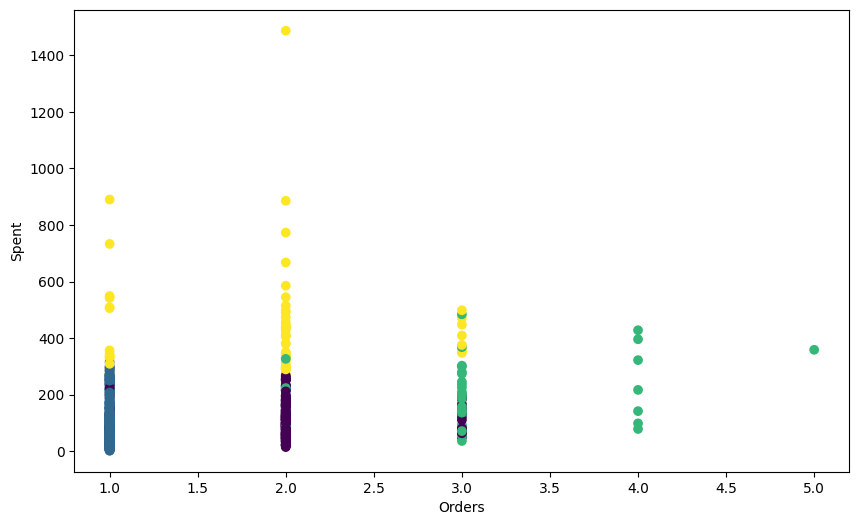

In [9]:
plt.figure(figsize=(10,6))

plt.scatter(

customer["Total_Orders"],

customer["Total_Spent"],

c=customer["Cluster"]

)

plt.xlabel("Orders")

plt.ylabel("Spent")

plt.show()

In [11]:
summary = customer.groupby("Cluster").agg({
    "Total_Orders": "mean",
    "Total_Items": "mean",
    "Total_Spent": "mean",
    "user_id": "count"
})

summary.rename(columns={"user_id": "No_of_Customers"}, inplace=True)

print(summary)

         Total_Orders  Total_Items  Total_Spent  No_of_Customers
Cluster                                                         
0            1.993485     2.674267   109.110033              307
1            1.000000     1.267202    68.030505              872
2            3.022727     5.500000   206.953182               44
3            1.875000     2.671875   431.023906               64
